In [208]:
!pip install -q segmentation-models-pytorch

In [209]:
import os
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import albumentations as A
import segmentation_models_pytorch as smp
from albumentations.pytorch import ToTensorV2

In [210]:
# ==========================================
# 1. КОНФИГУРАЦИЯ И НАСТРОЙКИ
# ==========================================
TEST_IMAGES_DIR = Path(r"/kaggle/input/competitions/dl-lab-3-product-segmentation/test_images")
WEIGHTS_DIR = Path(r"/kaggle/input/datasets/tkachenko1van/conf1-unetpp-effb4")
OUTPUT_CSV = "submission_conf1.csv"

IMG_SIZE = 320
THRESHOLD = 0.45
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Базовая нормализация ImageNet (такая же, как при обучении)
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [211]:
# ==========================================
# 2. ПОСТПРОЦЕССИНГ (Очистка маски)
# ==========================================
def postprocess_mask(mask: np.ndarray) -> np.ndarray:
    # 1. Выделение наибольшей компоненты связности (LCC)
    # Гарантируем, что на картинке останется только один цельный объект
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest_label).astype(np.uint8)
    else:
        return np.zeros_like(mask) # Если маска пустая
    
    # 2. Заливка дырок (Идеально против бликов от пакета)
    # Находим внешний контур объекта и заливаем его сплошным белым цветом
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(mask, contours, -1, 1, thickness=cv2.FILLED)
        
    # Возвращаем кристально чистую маску с оригинальными предсказанными краями
    return mask

def serialize_mask(mask2d: np.ndarray) -> str:
    return json.dumps(mask2d.tolist(), separators=(",", ":"))

In [212]:
# ==========================================
# 3. ФУНКЦИЯ ПРЕДСКАЗАНИЯ (Чистый Mean TTA)
# ==========================================
def predict_image(image_bgr: np.ndarray, models: list, threshold=THRESHOLD) -> np.ndarray:
    original_h, original_w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    augmented = val_transform(image=image_rgb)
    img_orig = augmented['image'].unsqueeze(0).to(DEVICE)

    # TTA: Создаем отражения
    img_h  = torch.flip(img_orig, dims=[3])
    img_v  = torch.flip(img_orig, dims=[2])
    img_hv = torch.flip(img_orig, dims=[2, 3])

    ensemble_probs = torch.zeros((1, 1, IMG_SIZE, IMG_SIZE), device=DEVICE)
    total_predictions = len(models) * 4 # 20 предсказаний (5 моделей * 4 TTA)
    
    for model in models:
        with torch.amp.autocast('cuda'):
            prob_orig = torch.sigmoid(model(img_orig))
            
            prob_h = torch.sigmoid(model(img_h))
            prob_h_inv = torch.flip(prob_h, dims=[3])
            
            prob_v = torch.sigmoid(model(img_v))
            prob_v_inv = torch.flip(prob_v, dims=[2])
            
            prob_hv = torch.sigmoid(model(img_hv))
            prob_hv_inv = torch.flip(prob_hv, dims=[2, 3])
            
            ensemble_probs += (prob_orig + prob_h_inv + prob_v_inv + prob_hv_inv)
            
    ensemble_probs /= total_predictions
    
    probs_np = ensemble_probs[0, 0].cpu().numpy().astype(np.float32)
    
    # Возвращаем вероятности к оригинальному размеру картинки
    if probs_np.shape != (original_h, original_w):
        probs_np = cv2.resize(probs_np, (original_w, original_h), interpolation=cv2.INTER_LINEAR)
        
    # Бинаризация: Применяем порог и получаем жесткую маску (0 или 1) типа uint8
    binary_mask = (probs_np > threshold).astype(np.uint8)
    
    # Применяем чистый постпроцессинг (LCC + Заливка)
    final_mask = postprocess_mask(binary_mask)
    
    return final_mask

In [213]:
# ==========================================
# 4. ЗАГРУЗКА МОДЕЛЕЙ И ТЕСТОВЫХ ИЗОБРАЖЕНИЙ
# ==========================================
models = []

# Загружаем все 5 фолдов
for fold in range(1, 6):
    weight_path = WEIGHTS_DIR / f"conf1_unetpp_effb4_fold{fold}.pth"
    if not weight_path.exists():
        print(f"⚠️ Файл не найден: {weight_path}")
        continue
        
    model = smp.UnetPlusPlus(encoder_name="efficientnet-b4", encoder_weights=None, in_channels=3, classes=1)
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    models.append(model)
    
print(f"✅ Загружено моделей: {len(models)}")

image_paths = sorted(list(TEST_IMAGES_DIR.glob("*.jpg"))) + sorted(list(TEST_IMAGES_DIR.glob("*.png")))
print(f"📸 Найдено тестовых изображений: {len(image_paths)}")

✅ Загружено моделей: 5
📸 Найдено тестовых изображений: 2000


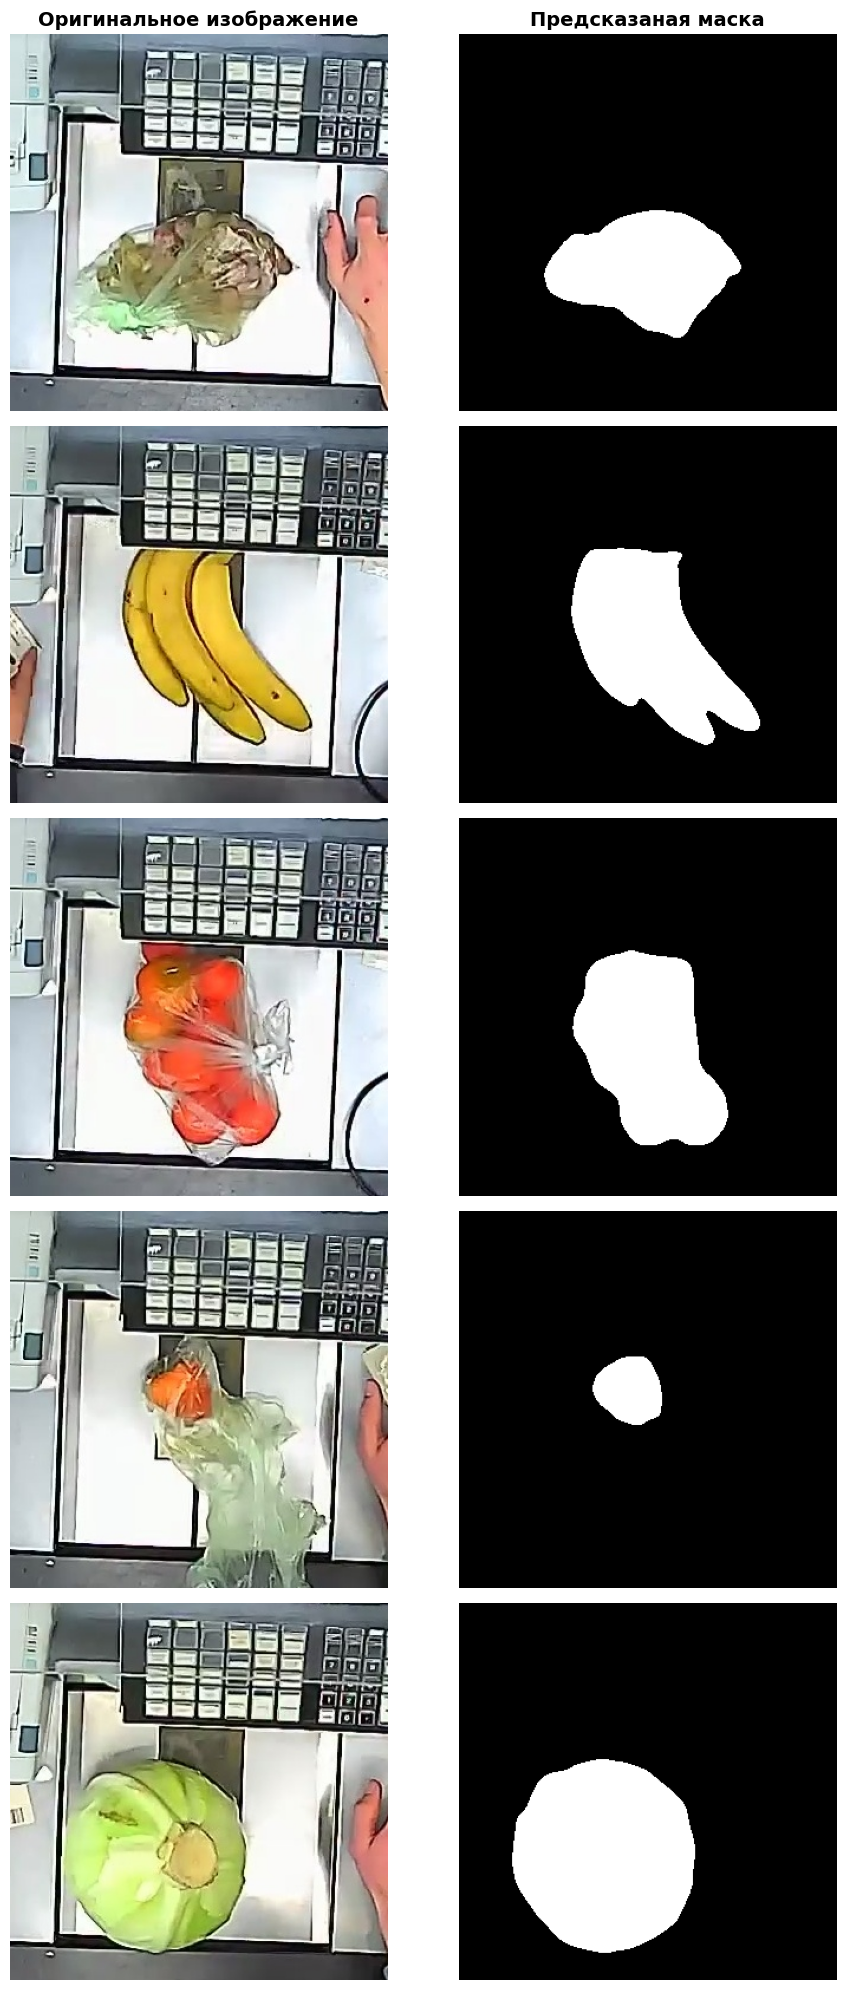

In [214]:
sample_paths = image_paths[:5]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))

# Добавляем заголовки только для первого ряда
axes[0, 0].set_title("Оригинальное изображение", fontsize=14, fontweight='bold')
axes[0, 1].set_title("Предсказаная маска", fontsize=14, fontweight='bold')

# Отключаем отрисовку осей (цифр) для красоты
for ax in axes.flatten():
    ax.axis('off')

# Прогоняем инференс и рисуем
with torch.inference_mode():
    for i, img_path in enumerate(sample_paths):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        mask = predict_image(img_bgr, models)

        axes[i, 0].imshow(img_rgb)
        axes[i, 1].imshow(mask, cmap='gray')

plt.tight_layout()
plt.show()

In [215]:
# ==========================================
# 5. ИНФЕРЕНС
# ==========================================
submission_data = []

# torch.inference_mode() работает быстрее и экономит больше памяти, чем torch.no_grad()
with torch.inference_mode():
    for img_path in tqdm(image_paths, desc="Обработка"):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print(f"[skip] Ошибка чтения: {img_path}")
            continue

        # Вызываем нашу модульную функцию
        final_mask = predict_image(img_bgr, models)

        submission_data.append({
            "ImageId": img_path.name,
            "mask": serialize_mask(final_mask),
        })

# Сохранение сабмита
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"🎉 Готово! Сабмит сохранен в: {OUTPUT_CSV}")

Обработка: 100%|██████████| 2000/2000 [17:19<00:00,  1.92it/s]


🎉 Готово! Сабмит сохранен в: submission_conf1.csv
